# Teacher Capture To Student Observer
Load multiple teacher-policy capture directories, verify that the rendered PNG frames are already binary, concatenate within-demo one-step transitions across demos, fit a sparse pixels-to-steps observer model, refine the learned dynamics under the paper's stability constraint using the teacher-policy controller `K`, and export the combined controller and observer matrices to JSON.

Latest frame directory: `/Users/imaginelenses/code/pixelsToSteps/python/captures/cartpole_binary_20260504_045757_frames`

Training rollout model: `nominal_linear`

Training demos selected: `3`

Total transition pairs across demos: `2615`

,demo_index,frame_dir,rollout_model,initial_angle_deg,frames,simulated_capture_duration_s
0,1,cartpole_binary_20260504_044730_frames,nominal_linear,5.000000,852,3.408
1,2,cartpole_binary_20260504_045753_frames,nominal_linear,7.096520,900,3.600
2,3,cartpole_binary_20260504_045757_frames,nominal_linear,-5.440142,863,3.452


...

First frame from latest demo: `frame_000000.png`

First frame unique values: `[0, 255]`

First frame is binary black/white: `True`

No blur or thresholding is applied. The captured PNG frames are already used directly as the observer measurement.

### First Frame Used For Regression

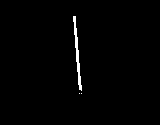

In [10]:
from pathlib import Path
import json

import cv2
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

MAX_TRAINING_DEMOS = 3


def list_capture_frame_dirs() -> list[Path]:
    candidate_roots = [Path.cwd() / "captures", Path.cwd() / "python" / "captures"]
    frame_dirs: list[Path] = []
    for root in candidate_roots:
        if not root.exists():
            continue
        for path in root.iterdir():
            metadata_path = path / "capture_metadata.json"
            trace_path = path / "capture_trace.csv"
            if path.is_dir() and metadata_path.exists() and trace_path.exists() and any(path.glob("frame_*.png")):
                frame_dirs.append(path)
    if not frame_dirs:
        raise FileNotFoundError("No complete capture directories were found under captures/ or python/captures/.")
    return frame_dirs


def load_capture_bundle(frame_dir: Path) -> dict[str, object]:
    metadata_path = frame_dir / "capture_metadata.json"
    trace_path = frame_dir / "capture_trace.csv"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")
    if not trace_path.exists():
        raise FileNotFoundError(f"Missing trace file: {trace_path}")

    metadata = json.loads(metadata_path.read_text(encoding="ascii"))
    trace = pd.read_csv(trace_path)
    frame_paths = [frame_dir / frame_name for frame_name in trace["frame_filename"]]
    if not frame_paths:
        raise FileNotFoundError(f"No frame entries were listed in {trace_path}")

    return {
        "frame_dir": frame_dir,
        "metadata_path": metadata_path,
        "trace_path": trace_path,
        "metadata": metadata,
        "trace": trace,
        "frame_paths": frame_paths,
        "mtime_ns": frame_dir.stat().st_mtime_ns,
    }


def select_training_bundles(max_training_demos: int | None) -> tuple[list[dict[str, object]], dict[str, object]]:
    bundles = [load_capture_bundle(frame_dir) for frame_dir in list_capture_frame_dirs()]
    latest_bundle = max(bundles, key=lambda bundle: int(bundle["mtime_ns"]))
    latest_metadata = latest_bundle["metadata"]
    target_rollout_model = str(latest_metadata.get("rollout_model", "constrained_physical"))
    target_frame_height_px = int(latest_metadata["frame_height_px"])
    target_frame_width_px = int(latest_metadata["frame_width_px"])
    target_frame_rate_hz = float(latest_metadata["frame_rate_hz"])

    matching_bundles = [
        bundle
        for bundle in bundles
        if str(bundle["metadata"].get("rollout_model", "constrained_physical")) == target_rollout_model
        and int(bundle["metadata"]["frame_height_px"]) == target_frame_height_px
        and int(bundle["metadata"]["frame_width_px"]) == target_frame_width_px
        and float(bundle["metadata"]["frame_rate_hz"]) == target_frame_rate_hz
    ]
    matching_bundles.sort(key=lambda bundle: int(bundle["mtime_ns"]))
    if max_training_demos is not None:
        matching_bundles = matching_bundles[-max_training_demos:]
    return matching_bundles, latest_bundle


def display_grayscale_image(title: str, image: np.ndarray) -> None:
    ok, encoded = cv2.imencode(".png", image)
    if not ok:
        raise RuntimeError(f"Failed to encode image for display: {title}")
    display(Markdown(f"### {title}"))
    display(Image(data=encoded.tobytes()))


def load_raw_frame(frame_path: Path) -> np.ndarray:
    frame = cv2.imread(str(frame_path), cv2.IMREAD_GRAYSCALE)
    if frame is None:
        raise RuntimeError(f"Failed to read frame: {frame_path}")
    return frame


selected_demo_bundles, latest_bundle = select_training_bundles(MAX_TRAINING_DEMOS)
latest_frame_dir = latest_bundle["frame_dir"]
latest_metadata_path = latest_bundle["metadata_path"]
latest_trace_path = latest_bundle["trace_path"]
latest_metadata = latest_bundle["metadata"]
latest_trace = latest_bundle["trace"]
frame_paths = latest_bundle["frame_paths"]
rollout_model = str(latest_metadata.get("rollout_model", "constrained_physical"))

demo_summary = pd.DataFrame(
    [
        {
            "demo_index": demo_index,
            "frame_dir": str(bundle["frame_dir"].name),
            "rollout_model": bundle["metadata"].get("rollout_model", "constrained_physical"),
            "initial_angle_deg": float(bundle["metadata"]["initial_angle_deg"]),
            "frames": int(bundle["metadata"]["frames_captured"]),
            "simulated_capture_duration_s": float(bundle["metadata"]["simulated_capture_duration_s"]),
        }
        for demo_index, bundle in enumerate(selected_demo_bundles, start=1)
    ]
)
total_training_transitions = int(demo_summary["frames"].sum())
training_demo_dirs = [str(bundle["frame_dir"]) for bundle in selected_demo_bundles]
training_demo_names = [bundle["frame_dir"].name for bundle in selected_demo_bundles]
training_demo_count = len(selected_demo_bundles)

first_frame_path = frame_paths[0]
first_frame = load_raw_frame(first_frame_path)
first_frame_unique_values = np.unique(first_frame).tolist()
first_frame_is_binary = bool(np.all(np.isin(first_frame_unique_values, [0, 255])))
processed_first_frame = first_frame
preprocessing_description = "No blur or thresholding is applied. The captured PNG frames are already used directly as the observer measurement."

display(Markdown(f"Latest frame directory: `{latest_frame_dir}`"))
display(Markdown(f"Training rollout model: `{rollout_model}`"))
display(Markdown(f"Training demos selected: `{training_demo_count}`"))
display(Markdown(f"Total transition pairs across demos: `{total_training_transitions}`"))
display(demo_summary)
display(Markdown(f"Anchor trace file: `{latest_trace_path.name}` with {len(latest_trace)} rows"))
display(Markdown(f"First frame from latest demo: `{first_frame_path.name}`"))
display(Markdown(f"First frame unique values: `{first_frame_unique_values}`"))
display(Markdown(f"First frame is binary black/white: `{first_frame_is_binary}`"))
display(Markdown(preprocessing_description))
display_grayscale_image("First Frame Used For Regression", processed_first_frame)

## Pixels-To-Steps Observer Equations
The teacher-policy state and control use step-domain units:

$$
\hat{x}_k = \begin{bmatrix} p_k \\ \dot{p}_k \\ \theta_k \\ \dot{\theta}_k \end{bmatrix},
\qquad
u_k \in \mathbb{R} \text{ is the cart step rate in steps/s.}
$$

The measurement is the flattened binary image frame:

$$
z_{k+1} = \operatorname{vec}(I_{k+1}),
$$

where $I_{k+1}$ is the captured binary frame and $z_{k+1}$ is the observer measurement vector.

### 1. KF Predict

$$
\hat{x}'_{k+1} = A\hat{x}_k + Bu_k
$$

### 2. KF Correct

$$
\hat{x}_{k+1} = \hat{x}'_{k+1} + K_t\bigl(z_{k+1} - C\hat{x}'_{k+1}\bigr)
$$

### 3. Combined Form

$$
\hat{x}_{k+1} = \underbrace{(I - K_t C)A}_{A_L}\hat{x}_k + \underbrace{(I - K_t C)B}_{B_L}u_k + \underbrace{K_t}_{L}z_{k+1}
$$

### 4. Learned Observer Used In This Notebook

$$
\hat{x}_{k+1} = A_L\hat{x}_k + B_L u_k + L z_{k+1} + d
$$

Here $u_k$ remains the LQR output in `steps/s`, so this is a pixels-to-steps observer rather than the paper's pixels-to-torques observer.

### 5. Regression Form

$$
\Theta W \approx X
$$

with

$$
\Theta = \begin{bmatrix} A_L & B_L & L & d \end{bmatrix},
\qquad
W_k = \begin{bmatrix} \hat{x}_k \\ u_k \\ z_{k+1} \\ 1 \end{bmatrix}
$$

and $X = x_{2:N}$ the teacher states at the next step.

### 6. Multiple Demonstrations

Each teacher demonstration contributes only its own within-demo one-step transitions. For demo $m$ with length $T_m$, the notebook forms $T_m-1$ valid pairs

$$
\left(\hat{x}^{(m)}_k, u^{(m)}_k, z^{(m)}_{k+1}, x^{(m)}_{k+1}\right), \qquad k = 1, \dots, T_m - 1,
$$

and resets the observer state at the start of each new rollout.

The full regression dataset is the concatenation of all demos:

$$
W = \begin{bmatrix}
W^{(1)} & W^{(2)} & \cdots & W^{(M)}
\end{bmatrix},
\qquad
X = \begin{bmatrix}
X^{(1)} & X^{(2)} & \cdots & X^{(M)}
\end{bmatrix}.
$$

No cross-demo transition is created between the last sample of demo $m$ and the first sample of demo $m+1$.

### 7. Sparse Fit

$$
\min_{\Theta}\ \|\Theta W - X\|_2^2 + \lambda\|\Theta\|_1
$$

The notebook first fits one LASSO model per state row, then partitions the learned coefficient matrix into $A_L$, $B_L$, $L$, and $d$.

### 8. Stability Constraint With The Teacher Policy Controller

The teacher policy uses

$$
u_k = -K\hat{x}_k.
$$

Substituting this into the learned observer gives the equivalent closed-loop observer dynamics

$$
A_{LK} = A_L - B_L K,
$$

which matches $(I - LC)(A - BK)$ when $A_L = (I-LC)A$ and $B_L = (I-LC)B$.

The stability constraint from the paper is then enforced as

$$
\begin{bmatrix}
I & A_{LK} \\
A_{LK}^\top & I
\end{bmatrix} \succ 0.
$$

### 9. Stability-Constrained Refinement Used Here

The notebook keeps the sparse image gain $L$ from the LASSO fit and refines $A_L$, $B_L$, and $d$ with the teacher-policy controller JSON using the convex problem

$$
\min_{A_L, B_L, d}\ \|\hat{X}(A_L, B_L, L, d) - X\|_2^2 + \rho\left(\|A_L - A_L^{\text{lasso}}\|_F^2 + \|B_L - B_L^{\text{lasso}}\|_F^2 + \|d - d^{\text{lasso}}\|_2^2\right)
$$

subject to

$$
\begin{bmatrix}
I & A_L - B_L K \\
(A_L - B_L K)^\top & I
\end{bmatrix} \succeq \varepsilon I.
$$

This applies the paper's stability condition with the actual teacher-policy `K` while preserving the sparse measurement map learned from the binary frames.

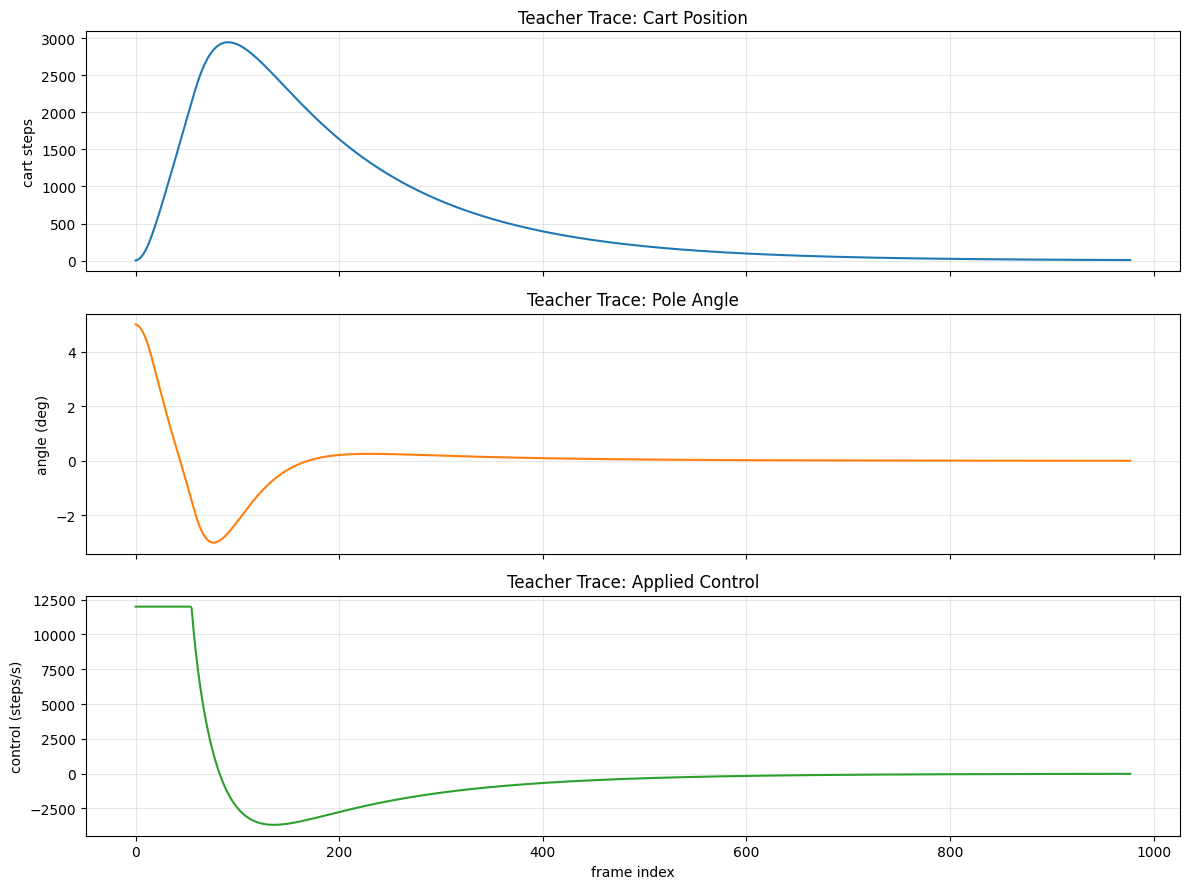

,frame_index,cart_position_steps,pole_angle_deg,applied_control_steps_s
0,0,1.2,4.995711,12000.0
1,1,4.8,4.982840,12000.0
2,2,10.8,4.961376,12000.0
3,3,19.2,4.931294,12000.0
4,4,30.0,4.892556,12000.0


In [2]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
frame_index = latest_trace["frame_index"].to_numpy()

axes[0].plot(frame_index, latest_trace["cart_position_steps"], color="tab:blue")
axes[0].set_ylabel("cart steps")
axes[0].set_title("Teacher Trace: Cart Position")
axes[0].grid(True, alpha=0.3)

axes[1].plot(frame_index, latest_trace["pole_angle_deg"], color="tab:orange")
axes[1].set_ylabel("angle (deg)")
axes[1].set_title("Teacher Trace: Pole Angle")
axes[1].grid(True, alpha=0.3)

axes[2].plot(frame_index, latest_trace["applied_control_steps_s"], color="tab:green")
axes[2].set_xlabel("frame index")
axes[2].set_ylabel("control (steps/s)")
axes[2].set_title("Teacher Trace: Applied Control")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

latest_trace[[
    "frame_index",
    "cart_position_steps",
    "pole_angle_deg",
    "applied_control_steps_s",
]].head()

In [11]:
import cvxpy as cp
from sklearn.linear_model import Lasso

from cartpole_lqr_gain import (
    PhysicalCartPoleParams,
    choose_cost_matrices,
    linearize_physical_cartpole,
    solve_discrete_lqr,
    verify_sign_conventions,
    write_generated_teacher_lqr_json,
)


def load_frame_vector(frame_path: Path) -> np.ndarray:
    frame = load_raw_frame(frame_path)
    return frame.astype(np.float64).reshape(-1) / 255.0


def capture_controller_json_path(frames_dir: Path, metadata: dict[str, object]) -> Path:
    controller_name = metadata.get("teacher_controller_json")
    if isinstance(controller_name, str) and controller_name:
        return frames_dir / controller_name
    return frames_dir / "teacher_lqr_controller.json"


def load_or_generate_teacher_controller(frames_dir: Path, metadata: dict[str, object]) -> tuple[Path, dict[str, object]]:
    controller_path = capture_controller_json_path(frames_dir, metadata)
    if controller_path.exists():
        return controller_path, json.loads(controller_path.read_text(encoding="utf-8"))

    default_params = PhysicalCartPoleParams()
    teacher_params = PhysicalCartPoleParams(
        sample_time_s=float(metadata.get("sample_time_s", 1.0 / float(metadata["frame_rate_hz"]))),
        max_step_rate_steps_s=float(metadata.get("max_step_rate_steps_s", default_params.max_step_rate_steps_s)),
        actuator_time_constant_s=float(
            metadata.get("actuator_time_constant_s", default_params.actuator_time_constant_s)
        ),
        max_cart_accel_steps_s2=float(
            metadata.get("max_cart_accel_steps_s2", default_params.max_cart_accel_steps_s2)
        ),
        control_penalty_r=float(metadata.get("control_penalty_r", default_params.control_penalty_r)),
        command_delay_s=float(metadata.get("command_delay_s", default_params.command_delay_s)),
    )
    a_discrete, b_discrete, _derived = linearize_physical_cartpole(teacher_params)
    q_matrix, r_matrix = choose_cost_matrices(teacher_params)
    teacher_gain, _riccati_solution, closed_loop_poles = solve_discrete_lqr(
        a_discrete,
        b_discrete,
        q_matrix,
        r_matrix,
    )
    sign_report = verify_sign_conventions(teacher_gain)
    controller_path = write_generated_teacher_lqr_json(
        teacher_params,
        q_matrix,
        r_matrix,
        teacher_gain,
        closed_loop_poles,
        sign_report,
        a_discrete=a_discrete,
        b_discrete=b_discrete,
        output_path=controller_path,
    )
    return controller_path, json.loads(controller_path.read_text(encoding="utf-8"))


def project_spectral_norm_ball(matrix: np.ndarray, max_singular_value: float) -> np.ndarray:
    left_singular_vectors, singular_values, right_singular_vectors_t = np.linalg.svd(
        matrix,
        full_matrices=False,
    )
    clipped_singular_values = np.minimum(singular_values, max_singular_value)
    return left_singular_vectors @ np.diag(clipped_singular_values) @ right_singular_vectors_t


demo_transition_counts: list[int] = []
selected_teacher_controller_paths: list[str] = []
teacher_controller = None
teacher_controller_path = None
teacher_gain = None

x_prev_segments = []
u_prev_segments = []
x_next_segments = []
z_segments = []

for bundle in selected_demo_bundles:
    bundle_frame_dir = bundle["frame_dir"]
    bundle_metadata = bundle["metadata"]
    bundle_trace = bundle["trace"]
    bundle_frame_paths = bundle["frame_paths"]

    bundle_controller_path, bundle_controller = load_or_generate_teacher_controller(bundle_frame_dir, bundle_metadata)
    bundle_teacher_gain = np.asarray(bundle_controller["K"], dtype=np.float64).reshape(1, 4)
    if teacher_gain is None:
        teacher_gain = bundle_teacher_gain
        teacher_controller = bundle_controller
        teacher_controller_path = bundle_controller_path
    elif not np.allclose(bundle_teacher_gain, teacher_gain, rtol=0.0, atol=1e-9):
        raise ValueError(
            "Selected demos do not share the same teacher-policy K. Filter the demos or regenerate them with matching teacher settings."
        )

    bundle_x_next = bundle_trace[[
        "cart_position_steps",
        "cart_velocity_steps_s",
        "pole_angle_rad",
        "pole_angle_rate_rad_s",
    ]].to_numpy(dtype=np.float64)
    bundle_initial_state = np.array(
        [0.0, 0.0, np.deg2rad(float(bundle_metadata["initial_angle_deg"])), 0.0],
        dtype=np.float64,
    )
    bundle_x_prev = np.vstack([bundle_initial_state, bundle_x_next[:-1]])
    bundle_u_prev = bundle_trace[["applied_control_steps_s"]].to_numpy(dtype=np.float64)
    bundle_z = np.stack([load_frame_vector(frame_path) for frame_path in bundle_frame_paths])

    x_prev_segments.append(bundle_x_prev)
    u_prev_segments.append(bundle_u_prev)
    x_next_segments.append(bundle_x_next)
    z_segments.append(bundle_z)
    demo_transition_counts.append(len(bundle_trace))
    selected_teacher_controller_paths.append(str(bundle_controller_path))

if teacher_gain is None or teacher_controller is None or teacher_controller_path is None:
    raise RuntimeError("No valid demos were loaded for the student-policy regression.")

x_prev = np.vstack(x_prev_segments)
u_prev = np.vstack(u_prev_segments)
x_next = np.vstack(x_next_segments)
z_matrix = np.vstack(z_segments)
W_without_bias = np.hstack([x_prev, u_prev, z_matrix])
X_targets = x_next
feature_mean = W_without_bias.mean(axis=0)
feature_scale = W_without_bias.std(axis=0)
feature_scale[feature_scale < 1e-12] = 1.0
W_scaled = (W_without_bias - feature_mean) / feature_scale

total_transition_count = int(X_targets.shape[0])
lasso_alpha = 1e-3
lasso_max_iter = 5000
lasso_tolerance = 1e-4
stability_margin = 1e-4
stability_regularization = 1e-3
stability_solver = "SCS"
stability_solver_eps = 1e-6
stability_solver_max_iters = 50000
state_names = [
    "cart_position_steps",
    "cart_velocity_steps_s",
    "pole_angle_rad",
    "pole_angle_rate_rad_s",
]

coefficient_rows = []
observer_bias_rows = []
rmse_lasso_by_state = {}
nonzero_by_state = {}

for state_index, state_name in enumerate(state_names):
    lasso_model = Lasso(
        alpha=lasso_alpha,
        fit_intercept=True,
        max_iter=lasso_max_iter,
        tol=lasso_tolerance,
    )
    lasso_model.fit(W_scaled, X_targets[:, state_index])
    coefficient_row = lasso_model.coef_ / feature_scale
    bias_value = lasso_model.intercept_ - feature_mean @ coefficient_row
    predictions = W_without_bias @ coefficient_row + bias_value

    coefficient_rows.append(coefficient_row)
    observer_bias_rows.append(bias_value)
    rmse_lasso_by_state[state_name] = float(
        np.sqrt(np.mean((predictions - X_targets[:, state_index]) ** 2))
    )
    nonzero_by_state[state_name] = int(np.count_nonzero(np.abs(coefficient_row) > 1e-12))

coefficient_matrix = np.vstack(coefficient_rows)
observer_bias_lasso = np.array(observer_bias_rows)
A_L_lasso = coefficient_matrix[:, :4]
B_L_lasso = coefficient_matrix[:, 4:5]
L_gain_pixels_to_steps = coefficient_matrix[:, 5:]
one_step_predictions_lasso = W_without_bias @ coefficient_matrix.T + observer_bias_lasso
A_LK_lasso = A_L_lasso - B_L_lasso @ teacher_gain
closed_loop_spectral_norm_lasso = float(np.linalg.norm(A_LK_lasso, ord=2))
closed_loop_max_abs_eig_lasso = float(np.max(np.abs(np.linalg.eigvals(A_LK_lasso))))

measurement_term = z_matrix @ L_gain_pixels_to_steps.T
ones_column = np.ones((x_prev.shape[0], 1), dtype=np.float64)
A_LK_var = cp.Variable((4, 4))
B_L_var = cp.Variable((4, 1))
d_var = cp.Variable(4)
A_LK_var.value = A_LK_lasso
B_L_var.value = B_L_lasso
d_var.value = observer_bias_lasso

predicted_targets = (
    x_prev @ (A_LK_var + B_L_var @ teacher_gain).T
    + u_prev @ B_L_var.T
    + measurement_term
    + ones_column @ cp.reshape(d_var, (1, 4), order="C")
)
lmi_block = cp.bmat(
    [
        [np.eye(4, dtype=np.float64), A_LK_var],
        [A_LK_var.T, np.eye(4, dtype=np.float64)],
    ]
)
stability_problem = cp.Problem(
    cp.Minimize(
        cp.sum_squares(predicted_targets - X_targets) / X_targets.shape[0]
        + stability_regularization
        * (
            cp.sum_squares(A_LK_var - A_LK_lasso)
            + cp.sum_squares(B_L_var - B_L_lasso)
            + cp.sum_squares(d_var - observer_bias_lasso)
        )
    ),
    [lmi_block >> (stability_margin * np.eye(8, dtype=np.float64))],
)
stability_problem.solve(
    solver=cp.SCS,
    eps=stability_solver_eps,
    max_iters=stability_solver_max_iters,
    warm_start=True,
    verbose=False,
)
if stability_problem.status not in {"optimal", "optimal_inaccurate"}:
    raise RuntimeError(f"Stability-constrained refinement failed with status: {stability_problem.status}")

A_LK_solver = np.array(A_LK_var.value, dtype=np.float64)
B_L = np.array(B_L_var.value, dtype=np.float64)
observer_bias = np.array(d_var.value, dtype=np.float64)
closed_loop_spectral_norm_solver = float(np.linalg.norm(A_LK_solver, ord=2))
closed_loop_max_abs_eig_solver = float(np.max(np.abs(np.linalg.eigvals(A_LK_solver))))
closed_loop_norm_limit = 1.0 - stability_margin
stability_projection_applied = closed_loop_spectral_norm_solver > closed_loop_norm_limit
A_LK = A_LK_solver
if stability_projection_applied:
    A_LK = project_spectral_norm_ball(A_LK_solver, closed_loop_norm_limit)

A_L = A_LK + B_L @ teacher_gain
Theta_matrix = np.hstack([A_L, B_L, L_gain_pixels_to_steps, observer_bias[:, None]])
one_step_predictions = x_prev @ A_L.T + u_prev @ B_L.T + measurement_term + observer_bias
closed_loop_spectral_norm = float(np.linalg.norm(A_LK, ord=2))
closed_loop_max_abs_eig = float(np.max(np.abs(np.linalg.eigvals(A_LK))))
rmse_stability_by_state = {
    state_name: float(np.sqrt(np.mean((one_step_predictions[:, state_index] - X_targets[:, state_index]) ** 2)))
    for state_index, state_name in enumerate(state_names)
}

observer_summary = pd.DataFrame(
    {
        "state": state_names,
        "rmse_lasso": [rmse_lasso_by_state[state_name] for state_name in state_names],
        "rmse_stability_constrained": [rmse_stability_by_state[state_name] for state_name in state_names],
        "nonzero_lasso_coefficients": [nonzero_by_state[state_name] for state_name in state_names],
    }
)

stability_report = {
    "teacher_controller_path": str(teacher_controller_path),
    "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
    "solver_status": stability_problem.status,
    "solver": stability_solver,
    "solver_eps": float(stability_solver_eps),
    "solver_max_iters": int(stability_solver_max_iters),
    "margin": float(stability_margin),
    "regularization": float(stability_regularization),
    "projection_applied": bool(stability_projection_applied),
    "closed_loop_spectral_norm_lasso": closed_loop_spectral_norm_lasso,
    "closed_loop_spectral_norm_solver": closed_loop_spectral_norm_solver,
    "closed_loop_spectral_norm_stable": closed_loop_spectral_norm,
    "closed_loop_max_abs_eig_lasso": closed_loop_max_abs_eig_lasso,
    "closed_loop_max_abs_eig_solver": closed_loop_max_abs_eig_solver,
    "closed_loop_max_abs_eig_stable": closed_loop_max_abs_eig,
}

demo_training_summary = pd.DataFrame(
    {
        "demo_name": training_demo_names,
        "transitions": demo_transition_counts,
        "teacher_controller_json": selected_teacher_controller_paths,
    }
)

# Export the current anchor capture metadata with the controller filename so future loads stay aligned.
if latest_metadata.get("teacher_controller_json") != teacher_controller_path.name:
    latest_metadata["teacher_controller_json"] = teacher_controller_path.name
    latest_metadata_path.write_text(json.dumps(latest_metadata, indent=2, sort_keys=True), encoding="ascii")

display(Markdown("Regression input uses the raw captured binary frames directly; no blur or thresholding is applied."))
display(Markdown(f"Teacher controller JSON: `{teacher_controller_path}`"))
display(Markdown(f"Teacher K: `{teacher_gain.reshape(-1).tolist()}`"))
display(Markdown(f"Training demos used: `{training_demo_count}`"))
display(Markdown(f"Total transition pairs: `{total_transition_count}`"))
display(Markdown(f"LASSO alpha: `{lasso_alpha}`"))
display(Markdown(f"W matrix shape: `{W_without_bias.shape}`"))
display(Markdown(f"X target shape: `{X_targets.shape}`"))
display(Markdown(f"L gain shape: `{L_gain_pixels_to_steps.shape}`"))
display(Markdown(f"Stability solver status: `{stability_problem.status}`"))
display(Markdown(f"Projection applied after solver: `{stability_projection_applied}`"))
display(Markdown(f"||A_L - B_L K||_2 before constraint: `{closed_loop_spectral_norm_lasso:.6f}`"))
display(Markdown(f"||A_L - B_L K||_2 from solver: `{closed_loop_spectral_norm_solver:.6f}`"))
display(Markdown(f"||A_L - B_L K||_2 after final projection: `{closed_loop_spectral_norm:.6f}`"))
display(demo_training_summary)
display(observer_summary)
display(Markdown("### A_L (stability constrained)"))
display(pd.DataFrame(A_L, index=state_names, columns=["p_k", "p_dot_k", "theta_k", "theta_dot_k"]))
display(Markdown("### B_L (stability constrained)"))
display(pd.DataFrame(B_L, index=state_names, columns=["u_k_steps_per_s"]))
display(Markdown("### d (stability constrained)"))
display(pd.Series(observer_bias, index=state_names, name="bias"))

/var/folders/mh/4_lxl3vj0fvfk7d2dk2ss6nc0000gn/T/ipykernel_64859/1303438658.py:222: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  stability_problem.solve(


Regression input uses the raw captured binary frames directly; no blur or thresholding is applied.

Teacher controller JSON: `/Users/imaginelenses/code/pixelsToSteps/python/captures/cartpole_binary_20260504_044730_frames/teacher_lqr_controller.json`

Teacher K: `[-2.1721540121212435, -2.7267616711913245, -297368.54492322763, -31334.012622122234]`

Training demos used: `3`

...

,p_k,p_dot_k,theta_k,theta_dot_k
cart_position_steps,0.956756,0.030905,-24.746634,-2.670003
cart_velocity_steps_s,-0.260050,0.769350,-21158.931376,-2229.590483
pole_angle_rad,-0.000008,-0.000005,-0.009829,-0.087872
pole_angle_rate_rad_s,0.000019,0.000020,2.783631,1.190948


### B_L (stability constrained)

,u_k_steps_per_s
cart_position_steps,8.418089e-05
cart_velocity_steps_s,7.115472e-02
pole_angle_rad,1.398549e-11
pole_angle_rate_rad_s,-9.016388e-06


### d (stability constrained)

cart_position_steps       3.217670
cart_velocity_steps_s    50.064376
pole_angle_rad            0.000315
pole_angle_rate_rad_s    -0.001241
Name: bias, dtype: float64

In [13]:
observer_json_path = Path.cwd() / "learned_pixels_to_steps_observer.json"
observer_payload = {
    "anchor_frame_dir": str(latest_frame_dir),
    "source_frame_dirs": training_demo_dirs,
    "source_trace_csv": latest_trace_path.name,
    "rollout_model": rollout_model,
    "demo_count": int(training_demo_count),
    "demo_transition_counts": demo_transition_counts,
    "total_transition_pairs": int(total_transition_count),
    "teacher_controller_json": str(teacher_controller_path),
    "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
    "frame_height_px": int(latest_metadata["frame_height_px"]),
    "frame_width_px": int(latest_metadata["frame_width_px"]),
    "frame_rate_hz": float(latest_metadata["frame_rate_hz"]),
    "state_order": [
        "cart_position_steps",
        "cart_velocity_steps_s",
        "pole_angle_rad",
        "pole_angle_rate_rad_s",
    ],
    "measurement_description": "flattened binary frame z_{k+1}",
    "control_units": "steps_per_second",
    "preprocessing": "none",
    "lasso_alpha": float(lasso_alpha),
    "lasso_max_iter": int(lasso_max_iter),
    "lasso_tolerance": float(lasso_tolerance),
    "stability_constraint": {
        "solver": stability_report["solver"],
        "solver_status": stability_report["solver_status"],
        "solver_eps": stability_report["solver_eps"],
        "solver_max_iters": stability_report["solver_max_iters"],
        "margin": stability_report["margin"],
        "regularization": stability_report["regularization"],
        "projection_applied": stability_report["projection_applied"],
        "closed_loop_spectral_norm_lasso": stability_report["closed_loop_spectral_norm_lasso"],
        "closed_loop_spectral_norm_solver": stability_report["closed_loop_spectral_norm_solver"],
        "closed_loop_spectral_norm_stable": stability_report["closed_loop_spectral_norm_stable"],
        "closed_loop_max_abs_eig_lasso": stability_report["closed_loop_max_abs_eig_lasso"],
        "closed_loop_max_abs_eig_solver": stability_report["closed_loop_max_abs_eig_solver"],
        "closed_loop_max_abs_eig_stable": stability_report["closed_loop_max_abs_eig_stable"],
    },
    "A_L": A_L.tolist(),
    "B_L": B_L.tolist(),
    "L": L_gain_pixels_to_steps.tolist(),
    "d": observer_bias.tolist(),
    "A_L_lasso": A_L_lasso.tolist(),
    "B_L_lasso": B_L_lasso.tolist(),
    "d_lasso": observer_bias_lasso.tolist(),
}
observer_json_path.write_text(json.dumps(observer_payload, indent=2), encoding="utf-8")

display(Markdown(f"Saved learned observer JSON to `{observer_json_path}`"))
display(Markdown(f"JSON size: `{observer_json_path.stat().st_size}` bytes"))

Saved learned observer JSON to `/Users/imaginelenses/code/pixelsToSteps/python/learned_pixels_to_steps_observer.json`

JSON size: `935590` bytes